In [1]:
import argparse
import pickle
import warnings
warnings.filterwarnings("ignore")
 
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
 
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

In [2]:
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
 
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [3]:
dt = np.load("curated_airfoils.npz", allow_pickle=True)


In [4]:
#If we want to go the parsing route
parser = argparse.ArgumentParser(description="Airfoil Surrogate Modeling")
parser.add_argument("--data", default="curated_airfoils.npz",
                    help="Path to curated_airfoils.npz")
parser.add_argument("--n_airfoils", type=int, default=2000,
                    help="Number of airfoils to use for training (default 2000)")
parser.add_argument("--seed", type=int, default=42)
args = parser.parse_known_args()

In [5]:
N_AIRFOILS     = 2000    # airfoils used for training (max 19164)
GPR_SUBSAMPLE  = 1500   # GPR training points (O(n^3) — keep <= 3000)
PINN_EPOCHS    = 200    # PINN training epochs
BNN_EPOCHS     = 200    # BNN training epochs
BNN_MC_SAMPLES = 50     # MC-Dropout inference samples
SEED           = 42
 
rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)
C1, C2, C3, C4, C5 = "#2196F3", "#F44336", "#4CAF50", "#FF9800", "#9C27B0"
CMAP_DARK  = "#0d1117"
CMAP_PANEL = "#161b22"

In [6]:
shapes = np.load('curated_airfoils.npz')['shapes']
classes = np.load('curated_airfoils.npz')['classes']
print("shapes: ", shapes.shape)
print('classes ', classes.shape)

shapes:  (19164, 1001, 2)
classes  (19164,)


In [7]:
def extract_features(shape: np.ndarray):
    """
    Return 18 geometric features from a (1001, 2) airfoil coordinate array.
 
    Features
    --------
    [0]  max_thickness       maximum thickness / chord
    [1]  x_max_thickness     chord-wise location of max thickness
    [2]  max_camber          maximum |camber| / chord
    [3]  x_max_camber        chord-wise location of max camber
    [4]  mean_camber         mean camber / chord
    [5]  te_thickness        trailing-edge thickness
    [6]  le_thickness        leading-edge thickness proxy (~1% chord)
    [7]  le_camber_slope     d(camber)/dx at leading edge
    [8]  te_camber_slope     d(camber)/dx at trailing edge
    [9-14]  thickness at x = 12, 25, 40, 60, 75, 90 %
    [15-17] camber   at x = 25, 50, 75 %
    """
    x, y   = shape[:, 0], shape[:, 1]
    le_idx = int(np.argmin(x))
 
    x_up = x[:le_idx + 1][::-1]
    y_up = y[:le_idx + 1][::-1]
    x_lo = x[le_idx:]
    y_lo = y[le_idx:]
 
    xc = np.linspace(0, 1, 200)
    try:
        yu = np.interp(xc, x_up, y_up)
        yl = np.interp(xc, x_lo, y_lo)
    except Exception:
        return None
 
    thick  = yu - yl
    camber = (yu + yl) / 2.0
 
    max_t   = float(np.max(thick))
    x_max_t = float(xc[np.argmax(thick)])
    max_c   = float(np.max(np.abs(camber)))
    x_max_c = float(xc[np.argmax(np.abs(camber))]) if max_c > 1e-8 else 0.5
    mean_c  = float(np.mean(camber))
    te_t    = float(thick[-1])
    le_t    = float(thick[2])
 
    dcamber  = np.gradient(camber, xc)
    le_slope = float(dcamber[2])
    te_slope = float(dcamber[-3])
 
    t_st = np.interp([0.12, 0.25, 0.40, 0.60, 0.75, 0.90], xc, thick)
    c_st = np.interp([0.25, 0.50, 0.75],                    xc, camber)
 
    feat = np.array([max_t, x_max_t, max_c, x_max_c, mean_c,
                     te_t, le_t, le_slope, te_slope, *t_st, *c_st])
    if np.any(np.isnan(feat)) or np.any(np.isinf(feat)):
        return None
    return feat

In [8]:
FEATURE_NAMES = [
    "max_thickness", "x_max_thickness", "max_camber", "x_max_camber",
    "mean_camber", "te_thickness", "le_thickness",
    "le_camber_slope", "te_camber_slope",
    "t@12%", "t@25%", "t@40%", "t@60%", "t@75%", "t@90%",
    "c@25%", "c@50%", "c@75%",
]
 
print("Extracting geometric features ...")
features_list, valid_idx = [], []
for i, shape in enumerate(shapes):
    f = extract_features(shape)
    if f is not None:
        features_list.append(f)
        valid_idx.append(i)
        
features   = np.array(features_list)
valid_idx  = np.array(valid_idx)
valid_cls  = classes[valid_idx]
print(f"  Valid airfoils : {len(features):,}")
 
max_t  = features[:, 0]
max_c  = features[:, 2]
mean_c = features[:, 4]

Extracting geometric features ...
  Valid airfoils : 19,164


PHYSICS-BASED Cl / Cd GENERATION
Cl - thin airfoil theory + Helmbold thickness correction + Kirchhoff flow-separation stall model
Cd - empirical drag polar  Cd = Cd0 + K*Cl^2 + post-stall drag surge

In [9]:
print("Generating physics-based Cl / Cd ...")
 
alpha_deg = np.linspace(-10, 25, 36)
 
alpha_L0     = -(2.0 * mean_c + 0.5 * features[:, 15] * 0.5)
thick_corr   = 1.0 + 0.77 * max_t
Cl_alpha_slp = 2.0 * np.pi * thick_corr
alpha_stall  = np.clip(8 + 20 * features[:, 6] + 5 * max_t - 3 * max_c, 8, 18)
Cl_max_arr   = 1.0 + 2.0 * max_c + 0.3 * max_t
Cd0          = np.clip(0.004 + 0.008 * max_t + 0.01 * max_t**2
                       + 0.5 * features[:, 5]**2, 0.003, 0.05)
K_arr        = 0.012 + 0.03 * max_c + 0.01 * np.abs(features[:, 8])

Generating physics-based Cl / Cd ...


In [10]:
def kirchhoff_cl(alpha_d, stall_d, Cl_max, Cl_alpha, al0):
    ar     = np.deg2rad(alpha_d)
    asr    = np.deg2rad(stall_d)
    Cl_lin = Cl_alpha * (ar - al0)
    delta  = ar - asr
    f      = np.where(delta <= 0, 1.0,
                      np.exp(-2.5 * delta / (0.1 + 0.3 * asr)))
    f      = np.clip(f, 0, 1)
    Cl_k   = Cl_max * ((1 + np.sqrt(f)) / 2) ** 2
    blend  = np.where(delta <= 0, 1.0, np.exp(-4.0 * np.clip(delta, 0, None)))
    Cl     = blend * Cl_lin + (1 - blend) * Cl_k
    f_neg  = np.exp(-2.5 * np.abs(np.minimum(delta, 0)) / (0.1 + 0.3 * asr))
    Cl_neg = -Cl_max * ((1 + np.sqrt(np.clip(f_neg, 0, 1))) / 2) ** 2
    return np.where(alpha_d < -stall_d, Cl_neg, Cl)
 
def compute_cd(alpha_d, stall_d, Cd0_i, K_i, Cl_arr):
    delta    = alpha_d - stall_d
    Cd_polar = Cd0_i + K_i * Cl_arr**2
    surge    = 0.8 * (1 - np.exp(-np.maximum(0, delta) / 3)) \
               * np.sin(np.deg2rad(np.abs(alpha_d)))**2
    return np.clip(Cd_polar + surge, 0.003, 3.0)

In [11]:
n_air = len(features)
n_aoa = len(alpha_deg)
Cl_all = np.zeros((n_air, n_aoa))
Cd_all = np.zeros((n_air, n_aoa))
 
for i in range(n_air):
    Cl_all[i] = kirchhoff_cl(alpha_deg, alpha_stall[i],
                              Cl_max_arr[i], Cl_alpha_slp[i], alpha_L0[i])
    Cd_all[i] = compute_cd(alpha_deg, alpha_stall[i],
                            Cd0[i], K_arr[i], Cl_all[i])
LD_all = Cl_all / np.clip(Cd_all, 1e-4, None)
print(f"  Cl in [{Cl_all.min():.3f}, {Cl_all.max():.3f}]")
print(f"  Cd in [{Cd_all.min():.4f}, {Cd_all.max():.4f}]")

  Cl in [-1.083, 2.193]
  Cd in [0.0040, 0.1892]


Build the Dataset

In [12]:
sel = rng.choice(n_air, min(N_AIRFOILS, n_air), replace=False)
 
X_geo      = np.repeat(features[sel], n_aoa, axis=0)
X_alpha    = np.tile(alpha_deg, len(sel))[:, None]
X          = np.hstack([X_geo, X_alpha])
y_Cl       = Cl_all[sel].ravel()
y_Cd       = Cd_all[sel].ravel()
alpha_flat = np.tile(alpha_deg, len(sel))
 
n_total = len(X)
n_train = int(0.8 * n_total)
perm    = rng.permutation(n_total)
tr, te  = perm[:n_train], perm[n_train:]
 
X_train, X_test     = X[tr],    X[te]
yCl_train, yCl_test = y_Cl[tr], y_Cl[te]
yCd_train, yCd_test = y_Cd[tr], y_Cd[te]
alpha_test   = alpha_flat[te]

In [13]:
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_train)
X_te_s = scaler.transform(X_test)
 
high  = np.abs(alpha_test) >= 10
stall = np.abs(alpha_test) >= 15

Output Results

In [14]:
def regime_metrics(y_true, y_pred, mask):
    return {"R2":  r2_score(y_true[mask], y_pred[mask]),
            "MAE": mean_absolute_error(y_true[mask], y_pred[mask])}

def print_metrics(name, Cl_p, Cd_p):
    all_m = np.ones(len(yCl_test), bool)
    print(f"\n  [{name}]")
    print(f"  {'Regime':<14} {'Cl R2':>9} {'Cl MAE':>9} {'Cd R2':>9} {'Cd MAE':>9}")
    print(f"  {'-'*52}")
    for label, mask in [("All AoA", all_m), ("|a|>=10", high), ("|a|>=15", stall)]:
        mCl = regime_metrics(yCl_test, Cl_p, mask)
        mCd = regime_metrics(yCd_test, Cd_p, mask)
        print(f"  {label:<14} {mCl['R2']:>9.4f} {mCl['MAE']:>9.4f}"
              f" {mCd['R2']:>9.4f} {mCd['MAE']:>9.6f}")

all_preds = {}   # name -> (Cl_pred, Cd_pred)

Models

Model 1 - MLP Neural Network

In [15]:
mlp_kw = dict(hidden_layer_sizes=(128, 64, 32), activation="relu",
              max_iter=300, random_state=SEED,
              early_stopping=True, n_iter_no_change=15,
              validation_fraction=0.1)
 
mlp_Cl = MLPRegressor(**mlp_kw)
mlp_Cl.fit(X_tr_s, yCl_train)
Cl_pred_mlp = mlp_Cl.predict(X_te_s)
 
mlp_Cd = MLPRegressor(**mlp_kw)
mlp_Cd.fit(X_tr_s, yCd_train)
Cd_pred_mlp = mlp_Cd.predict(X_te_s)

In [16]:
print_metrics("MLP", Cl_pred_mlp, Cd_pred_mlp)


  [MLP]
  Regime             Cl R2    Cl MAE     Cd R2    Cd MAE
  ----------------------------------------------------
  All AoA           0.9998    0.0055    0.9998  0.000403
  |a|>=10           0.9996    0.0048    0.9999  0.000351
  |a|>=15           0.9946    0.0048    0.9997  0.000360


In [17]:
all_preds["MLP"] = (Cl_pred_mlp, Cd_pred_mlp)

Model 2 - Gaussian Process Regression (with uncertainty)

In [18]:
gpr_idx    = rng.choice(n_train, min(GPR_SUBSAMPLE, n_train), replace=False)
X_gpr_tr   = X_tr_s[gpr_idx]
yCl_gpr_tr = yCl_train[gpr_idx]
yCd_gpr_tr = yCd_train[gpr_idx]
 
kernel = 1.0 * RBF(length_scale=1.0) + WhiteKernel(noise_level=1e-3)

In [19]:
gpr_Cl = GaussianProcessRegressor(kernel=kernel, random_state=SEED,
                                   n_restarts_optimizer=2, normalize_y=True)
gpr_Cl.fit(X_gpr_tr, yCl_gpr_tr)
Cl_pred_gpr, Cl_gpr_std = gpr_Cl.predict(X_te_s, return_std=True)
 
gpr_Cd = GaussianProcessRegressor(kernel=kernel, random_state=SEED,
                                   n_restarts_optimizer=2, normalize_y=True)
gpr_Cd.fit(X_gpr_tr, yCd_gpr_tr)
Cd_pred_gpr, Cd_gpr_std = gpr_Cd.predict(X_te_s, return_std=True)

In [20]:
print_metrics("GPR", Cl_pred_gpr, Cd_pred_gpr)
print(f"\n  Mean epistemic uncertainty:")
print(f"    Cl sigma = {Cl_gpr_std.mean():.4f}  (high-AoA: {Cl_gpr_std[high].mean():.4f})")
print(f"    Cd sigma = {Cd_gpr_std.mean():.6f}  (high-AoA: {Cd_gpr_std[high].mean():.6f})")


  [GPR]
  Regime             Cl R2    Cl MAE     Cd R2    Cd MAE
  ----------------------------------------------------
  All AoA           0.9681    0.0752    0.9910  0.003139
  |a|>=10           0.9359    0.0570    0.9854  0.002949
  |a|>=15           0.3574    0.0470    0.9593  0.002779

  Mean epistemic uncertainty:
    Cl sigma = 0.1084  (high-AoA: 0.1110)
    Cd sigma = 0.004092  (high-AoA: 0.004191)


In [21]:
all_preds["GPR"] = (Cl_pred_gpr, Cd_pred_gpr)

Model 3 - Physics-Informed Neural Network (PINN)
Loss = MSE(Cl) + lambda_phys * MSE( dCl/d_alpha - 2*pi )
The physics residual forces the model to respect thin airfoil theory (dCl/d_alpha = 2*pi per radian) in the linear regime

In [22]:
N_FEAT = X_tr_s.shape[1]   # 19
 
class PINNNet(nn.Module):
    def __init__(self, in_dim=N_FEAT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.Tanh(),
            nn.Linear(128,    64),  nn.Tanh(),
            nn.Linear(64,     32),  nn.Tanh(),
            nn.Linear(32,      1),
        )
 
    def forward(self, x):
        return self.net(x).squeeze(-1)
 
 
def pinn_loss(model, x_batch, y_batch, lambda_phys=0.05):
    """MSE loss + physics residual enforcing dCl/d_alpha = 2*pi."""
    x_batch = x_batch.clone().requires_grad_(True)
    Cl_pred = model(x_batch)
    mse     = nn.MSELoss()(Cl_pred, y_batch)
 
    # dCl w.r.t. all inputs; last column is alpha (scaled)
    grad      = torch.autograd.grad(Cl_pred.sum(), x_batch,
                                     create_graph=True)[0]
    dCl_da    = grad[:, -1]
    alpha_std = torch.tensor(scaler.scale_[-1], dtype=torch.float32)
    dCl_da_unscaled = dCl_da / alpha_std          # chain rule: unscale
    phys = ((dCl_da_unscaled - 2 * torch.pi) ** 2).mean()
 
    return mse + lambda_phys * phys
 
def train_pinn(model, X_tr, y_tr, epochs, lr=1e-3, batch=512):
    opt    = optim.Adam(model.parameters(), lr=lr)  #ADAM optimizer
    sched  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    ds     = TensorDataset(torch.tensor(X_tr, dtype=torch.float32),
                            torch.tensor(y_tr, dtype=torch.float32))
    loader = DataLoader(ds, batch_size=batch, shuffle=True)
    model.train()
    for ep in range(1, epochs + 1):
        epoch_loss = 0.0
        for xb, yb in loader:
            opt.zero_grad()
            loss = pinn_loss(model, xb, yb)
            loss.backward()
            opt.step()
            epoch_loss += loss.item()
        sched.step()
        if ep % 50 == 0:
            print(f"    epoch {ep:>4}/{epochs}  loss={epoch_loss/len(loader):.6f}")
    return model


In [23]:

pinn_Cl = train_pinn(PINNNet(), X_tr_s, yCl_train, epochs=PINN_EPOCHS)

pinn_Cd = train_pinn(PINNNet(), X_tr_s, yCd_train, epochs=PINN_EPOCHS)
 
with torch.no_grad():
    X_te_t       = torch.tensor(X_te_s, dtype=torch.float32)
    Cl_pred_pinn = pinn_Cl(X_te_t).numpy()
    Cd_pred_pinn = pinn_Cd(X_te_t).numpy()

    epoch   50/200  loss=1.935084
    epoch  100/200  loss=1.849460
    epoch  150/200  loss=1.816978
    epoch  200/200  loss=1.802858
    epoch   50/200  loss=1.895364
    epoch  100/200  loss=1.634304
    epoch  150/200  loss=1.501695
    epoch  200/200  loss=1.485413


In [24]:
print_metrics("PINN", Cl_pred_pinn, Cd_pred_pinn)


  [PINN]
  Regime             Cl R2    Cl MAE     Cd R2    Cd MAE
  ----------------------------------------------------
  All AoA           0.9828    0.0380   -0.4608  0.033066
  |a|>=10           0.9551    0.0399   -0.6002  0.035921
  |a|>=15          -0.0417    0.0515   -4.1873  0.046063


In [25]:
all_preds["PINN"] = (Cl_pred_pinn, Cd_pred_pinn)

Model 4 - MC-Dropout Bayesian Neural Network (BNN)
Dropout stays active at inference; N forward passes yield a distribution:
mean  -> point prediction
std   -> epistemic uncertainty estimate

In [26]:
class MCDropoutNet(nn.Module):
    def __init__(self, in_dim=N_FEAT, p_drop=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(128,    64),  nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(64,     32),  nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(32,      1),
        )
 
    def forward(self, x):
        return self.net(x).squeeze(-1)
 
 
def train_bnn(model, X_tr, y_tr, epochs, lr=1e-3, batch=512):
    opt    = optim.Adam(model.parameters(), lr=lr)
    sched  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    ds     = TensorDataset(torch.tensor(X_tr, dtype=torch.float32),
                            torch.tensor(y_tr, dtype=torch.float32))
    loader = DataLoader(ds, batch_size=batch, shuffle=True)
    criterion = nn.MSELoss()
    model.train()
    for ep in range(1, epochs + 1):
        epoch_loss = 0.0
        for xb, yb in loader:
            opt.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            opt.step()
            epoch_loss += loss.item()
        sched.step()
        if ep % 50 == 0:
            print(f"    epoch {ep:>4}/{epochs}  loss={epoch_loss/len(loader):.6f}")
    return model
 
def mc_predict(model, X_np, n_samples=BNN_MC_SAMPLES):
    """Run N stochastic forward passes with dropout active."""
    model.train()   # keep dropout on during inference
    X_t   = torch.tensor(X_np, dtype=torch.float32)
    preds = torch.stack([model(X_t) for _ in range(n_samples)])
    return preds.mean(0).detach().numpy(), preds.std(0).detach().numpy()

In [27]:
bnn_Cl = train_bnn(MCDropoutNet(), X_tr_s, yCl_train, epochs=BNN_EPOCHS)
bnn_Cd = train_bnn(MCDropoutNet(), X_tr_s, yCd_train, epochs=BNN_EPOCHS)
 
Cl_pred_bnn, Cl_bnn_std = mc_predict(bnn_Cl, X_te_s)
Cd_pred_bnn, Cd_bnn_std = mc_predict(bnn_Cd, X_te_s)

    epoch   50/200  loss=0.005745
    epoch  100/200  loss=0.004393
    epoch  150/200  loss=0.004096
    epoch  200/200  loss=0.004055
    epoch   50/200  loss=0.000029
    epoch  100/200  loss=0.000025
    epoch  150/200  loss=0.000023
    epoch  200/200  loss=0.000023


In [28]:
print_metrics("MC-Dropout BNN", Cl_pred_bnn, Cd_pred_bnn)
print(f"\n  Mean epistemic uncertainty:")
print(f"    Cl sigma = {Cl_bnn_std.mean():.4f}  (high-AoA: {Cl_bnn_std[high].mean():.4f})")
print(f"    Cd sigma = {Cd_bnn_std.mean():.6f}  (high-AoA: {Cd_bnn_std[high].mean():.6f})")


  [MC-Dropout BNN]
  Regime             Cl R2    Cl MAE     Cd R2    Cd MAE
  ----------------------------------------------------
  All AoA           0.9996    0.0089    0.9997  0.000678
  |a|>=10           0.9992    0.0082    0.9994  0.000755
  |a|>=15           0.9891    0.0076    0.9981  0.000892

  Mean epistemic uncertainty:
    Cl sigma = 0.0584  (high-AoA: 0.0546)
    Cd sigma = 0.004227  (high-AoA: 0.004815)


In [29]:
all_preds["BNN"] = (Cl_pred_bnn, Cd_pred_bnn)

Random Forest Model

In [30]:
rf_Cl = RandomForestRegressor(n_estimators=200, max_depth=12,
                               n_jobs=-1, random_state=SEED)
rf_Cl.fit(X_train, yCl_train)
 
rf_Cd = RandomForestRegressor(n_estimators=200, max_depth=12,
                               n_jobs=-1, random_state=SEED)
rf_Cd.fit(X_train, yCd_train)
 
Cl_pred_rf = rf_Cl.predict(X_test)
Cd_pred_rf = rf_Cd.predict(X_test)

In [31]:
Cl_tree_preds = np.stack([t.predict(X_test) for t in rf_Cl.estimators_])
Cd_tree_preds = np.stack([t.predict(X_test) for t in rf_Cd.estimators_])
Cl_rf_std = Cl_tree_preds.std(0)
Cd_rf_std = Cd_tree_preds.std(0)
 
print_metrics("Random Forest", Cl_pred_rf, Cd_pred_rf)
print(f"\n  Mean prediction uncertainty:")
print(f"    Cl sigma = {Cl_rf_std.mean():.4f}  (high-AoA: {Cl_rf_std[high].mean():.4f})")
print(f"    Cd sigma = {Cd_rf_std.mean():.6f}  (high-AoA: {Cd_rf_std[high].mean():.6f})")


  [Random Forest]
  Regime             Cl R2    Cl MAE     Cd R2    Cd MAE
  ----------------------------------------------------
  All AoA           0.9999    0.0034    1.0000  0.000208
  |a|>=10           0.9997    0.0040    0.9999  0.000220
  |a|>=15           0.9972    0.0032    0.9998  0.000233

  Mean prediction uncertainty:
    Cl sigma = 0.0054  (high-AoA: 0.0048)
    Cd sigma = 0.000297  (high-AoA: 0.000386)


In [32]:
all_preds["Random Forest"] = (Cl_pred_rf, Cd_pred_rf)

Light GBM Model

In [33]:
from lightgbm import LGBMRegressor

lgbm_kw = dict(n_estimators=500, learning_rate=0.05, num_leaves=63,
                   subsample=0.8, colsample_bytree=0.8,
                   random_state=SEED, n_jobs=-1, verbose=-1)
 
lgbm_Cl = LGBMRegressor(**lgbm_kw)
lgbm_Cl.fit(X_train, yCl_train)
 
lgbm_Cd = LGBMRegressor(**lgbm_kw)
lgbm_Cd.fit(X_train, yCd_train)
 
Cl_pred_lgbm = lgbm_Cl.predict(X_test)
Cd_pred_lgbm = lgbm_Cd.predict(X_test)
 
print_metrics("LightGBM", Cl_pred_lgbm, Cd_pred_lgbm)


  [LightGBM]
  Regime             Cl R2    Cl MAE     Cd R2    Cd MAE
  ----------------------------------------------------
  All AoA           1.0000    0.0021    1.0000  0.000115
  |a|>=10           1.0000    0.0015    1.0000  0.000110
  |a|>=15           0.9996    0.0014    1.0000  0.000100


In [34]:
all_preds["LightGBM"] = (Cl_pred_lgbm, Cd_pred_lgbm)

Weighted Ensemble

In [35]:
ens_models = {
    "MLP":           (Cl_pred_mlp,  Cd_pred_mlp),
    "LightGBM":      (Cl_pred_lgbm, Cd_pred_lgbm),
    "Random Forest": (Cl_pred_rf,   Cd_pred_rf),
    "GPR":           (Cl_pred_gpr,  Cd_pred_gpr),
    "PINN":          (Cl_pred_pinn, Cd_pred_pinn),
    "BNN":           (Cl_pred_bnn,  Cd_pred_bnn),
}

raw_weights = {name: max(0.0, r2_score(yCl_test, Cl_p))
               for name, (Cl_p, _) in ens_models.items()}

total_w  = sum(raw_weights.values())

weights  = {k: v / total_w for k, v in raw_weights.items()}

In [36]:
print("  Model weights (based on Cl R2):")
for name, w in weights.items():
    print(f"    {name:<18}  weight = {w:.4f}  (R2 = {raw_weights[name]:.4f})")

  Model weights (based on Cl R2):
    MLP                 weight = 0.1680  (R2 = 0.9998)
    LightGBM            weight = 0.1681  (R2 = 1.0000)
    Random Forest       weight = 0.1680  (R2 = 0.9999)
    GPR                 weight = 0.1627  (R2 = 0.9681)
    PINN                weight = 0.1652  (R2 = 0.9828)
    BNN                 weight = 0.1680  (R2 = 0.9996)


In [38]:
Cl_pred_ens = sum(w * ens_models[n][0] for n, w in weights.items())
Cd_pred_ens = sum(w * ens_models[n][1] for n, w in weights.items())
 
print_metrics("Weighted Ensemble", Cl_pred_ens, Cd_pred_ens)
all_preds["Ensemble"] = (Cl_pred_ens, Cd_pred_ens)


  [Weighted Ensemble]
  Regime             Cl R2    Cl MAE     Cd R2    Cd MAE
  ----------------------------------------------------
  All AoA           0.9982    0.0167    0.9593  0.005666
  |a|>=10           0.9969    0.0127    0.9564  0.006023
  |a|>=15           0.9581    0.0121    0.8600  0.007600


In [39]:
UQ_THRESHOLD_CL = 0.15
needs_ham2d     = (Cl_gpr_std > UQ_THRESHOLD_CL) | (Cd_gpr_std > 0.01)
print(f"\n  HAM2D fallback triggered for {needs_ham2d.sum()} / {len(needs_ham2d)}"
      f" test samples  ({needs_ham2d.mean()*100:.1f}%)")


  HAM2D fallback triggered for 1898 / 14400 test samples  (13.2%)


PGA Analysis

In [40]:
scaler_geo  = StandardScaler()
feat_scaled = scaler_geo.fit_transform(features)
pca         = PCA(n_components=8, random_state=SEED)
pga_coords  = pca.fit_transform(feat_scaled)
expl_var    = pca.explained_variance_ratio_

In [41]:
print("Explained variance per PGA mode:")
for i, v in enumerate(expl_var):
    print(f" PGA-{i+1}: {v*100:.1f}%  (cumulative {expl_var[:i+1].sum()*100:.1f}%)")

Explained variance per PGA mode:
 PGA-1: 51.4%  (cumulative 51.4%)
 PGA-2: 18.9%  (cumulative 70.3%)
 PGA-3: 8.8%  (cumulative 79.1%)
 PGA-4: 5.6%  (cumulative 84.6%)
 PGA-5: 4.7%  (cumulative 89.3%)
 PGA-6: 3.7%  (cumulative 93.0%)
 PGA-7: 2.7%  (cumulative 95.7%)
 PGA-8: 1.8%  (cumulative 97.5%)


In [42]:
idx_5  = int(np.argmin(np.abs(alpha_deg - 5)))
LD_5   = np.clip(LD_all[:, idx_5], 0, 80)
 
window     = (pga_coords[:, 0].max() - pga_coords[:, 0].min()) / 10
pga1_range = np.linspace(pga_coords[:, 0].min(), pga_coords[:, 0].max(), 50)
mean_LD    = []
for p1 in pga1_range:
    mask = np.abs(pga_coords[:, 0] - p1) < window
    mean_LD.append(np.clip(LD_5[mask], 0, 80).mean() if mask.sum() > 5 else np.nan)

In [43]:
mean_LD  = np.array(mean_LD)
opt_pga1 = pga1_range[int(np.nanargmax(mean_LD))]
print(f"\n  Optimal PGA-1 = {opt_pga1:.3f}")
print(f"  -> max_t ~ {features[np.argmin(np.abs(pga_coords[:,0]-opt_pga1)), 0]*100:.1f}%c")


  Optimal PGA-1 = -4.906
  -> max_t ~ 0.0%c


In [44]:
best_i   = int(np.argmax(LD_5))
print(f"\n  Best L/D airfoil : {valid_cls[best_i]}  "
      f"(L/D={LD_5[best_i]:.1f}, t={max_t[best_i]*100:.1f}%, "
      f"c={max_c[best_i]*100:.2f}%)")


  Best L/D airfoil : GA 30-018  (L/D=72.1, t=0.0%, c=0.00%)


Visuals

In [45]:
model_order  = ["MLP", "LightGBM", "Random Forest", "GPR", "PINN", "BNN", "Ensemble"]
model_colors = [C1, C2, C3, C4, C5, "#FFD700", "#00BCD4"]

In [46]:
def dark_fig(nrows, ncols, figsize, title=""):
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    fig.patch.set_facecolor(CMAP_DARK)
    for ax in np.array(axes).flat:
        ax.set_facecolor(CMAP_PANEL)
        ax.tick_params(colors="white")
        for sp in ax.spines.values():
            sp.set_edgecolor("#30363d")
        ax.title.set_color("white")
        ax.xaxis.label.set_color("white")
        ax.yaxis.label.set_color("white")
    if title:
        fig.suptitle(title, fontsize=13, color="white", fontweight="bold", y=0.98)
    return fig, axes
 
def cb_style(cb):
    cb.ax.yaxis.label.set_color("white")
    cb.ax.yaxis.set_tick_params(color="white")
    plt.setp(cb.ax.yaxis.get_ticklabels(), color="white")
 
 
def leg(ax, **kw):
    ax.legend(facecolor=CMAP_DARK, edgecolor="#30363d", labelcolor="white", **kw)

In [50]:
%matplotlib inline

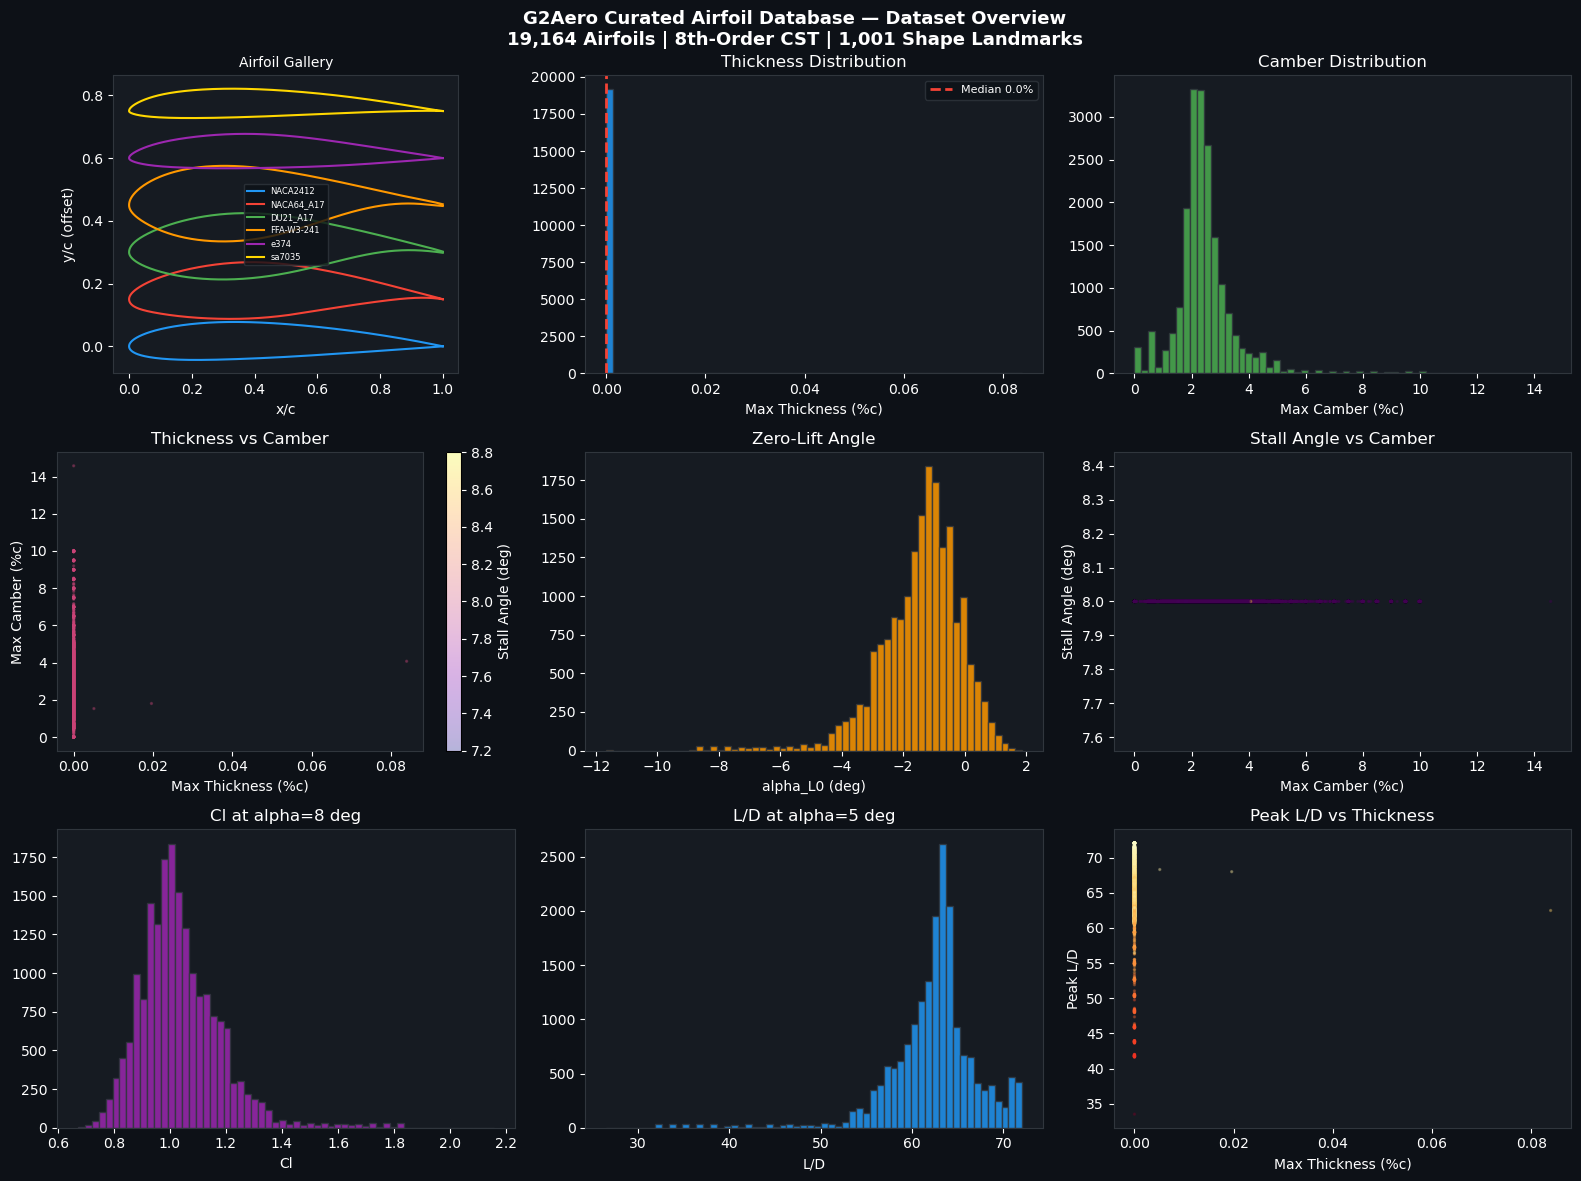

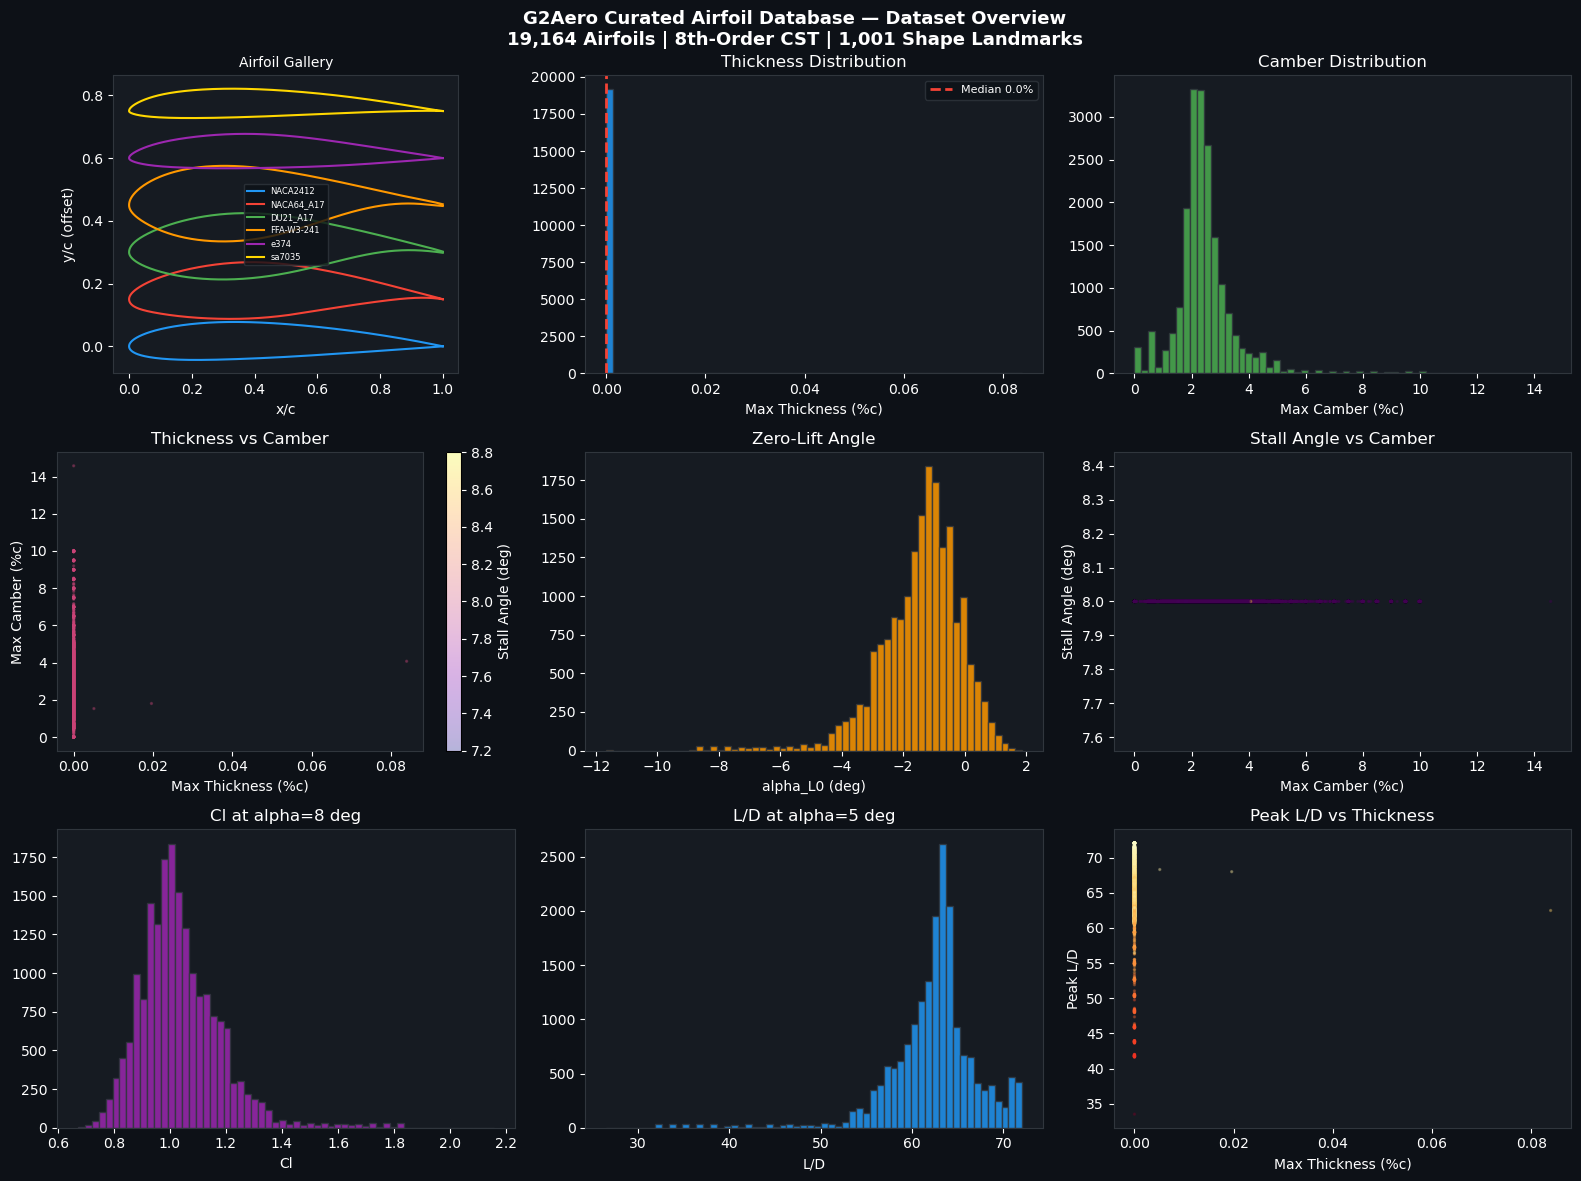

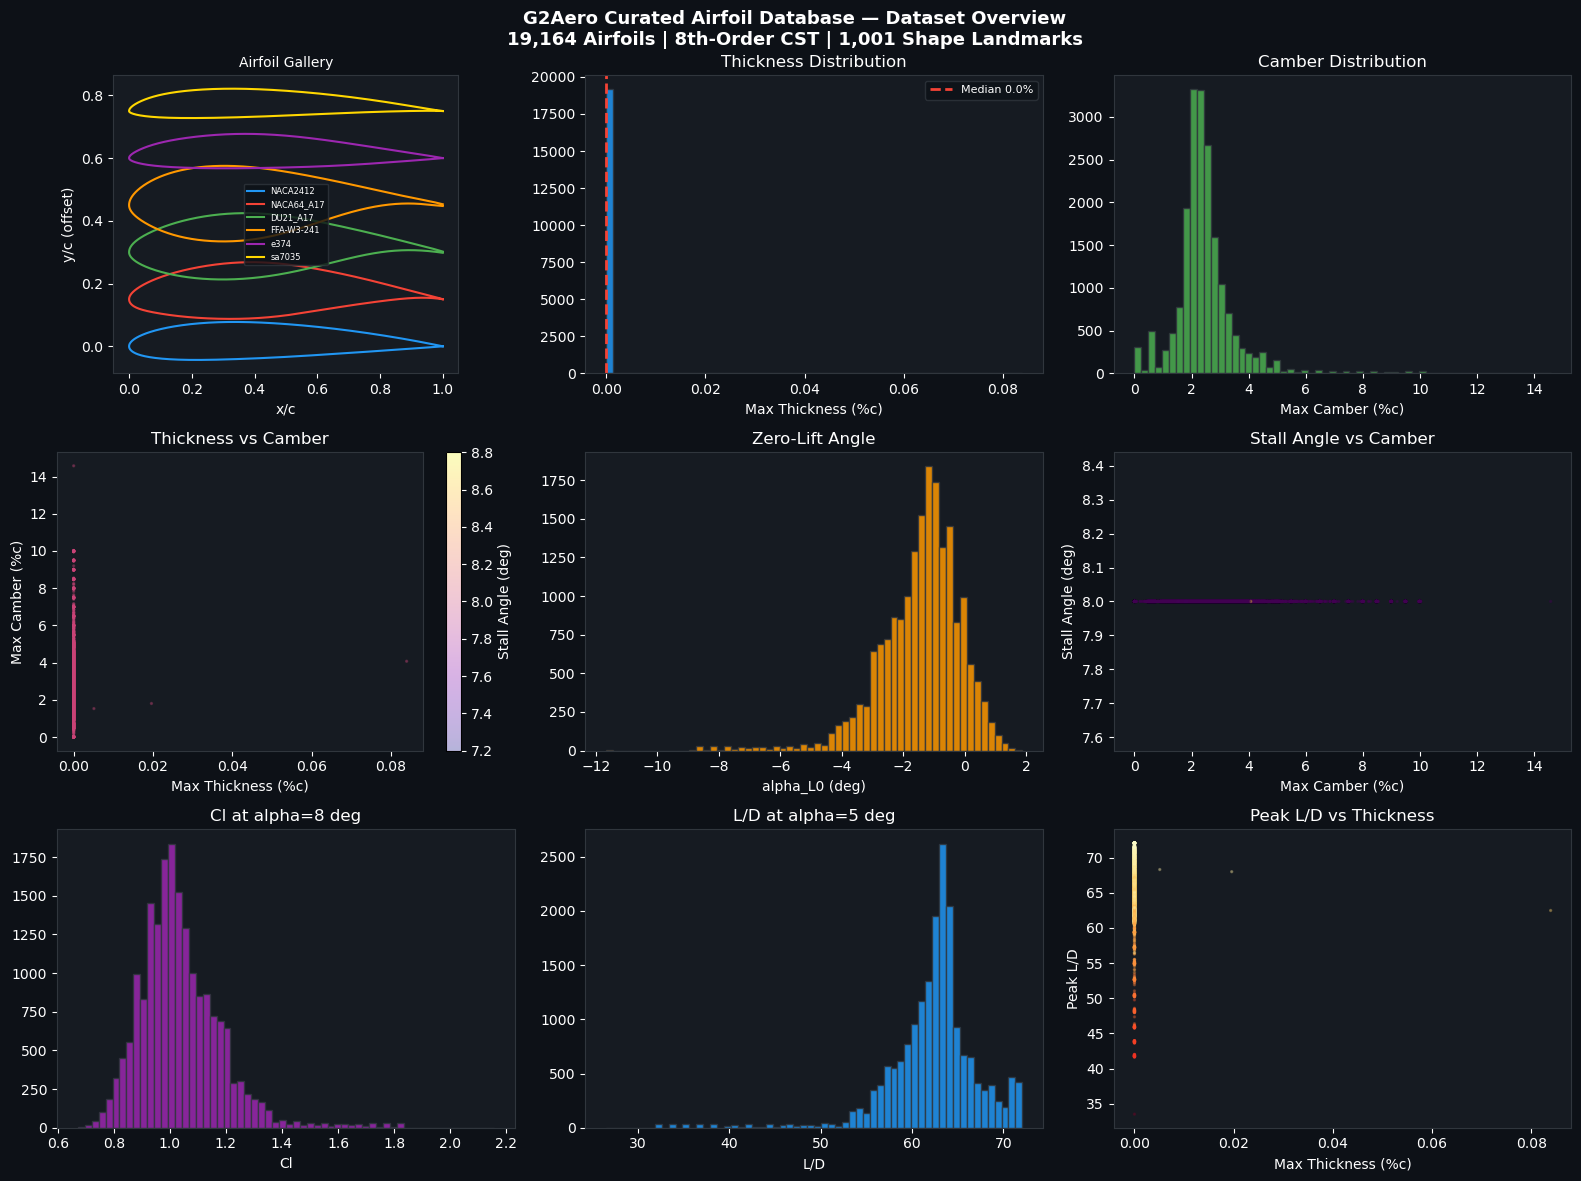

In [51]:
# ── Fig 1 : Dataset Overview ──────────────────────────────────────────────
fig1, axes = dark_fig(3, 3, (16, 12),
    "G2Aero Curated Airfoil Database — Dataset Overview\n"
    "19,164 Airfoils | 8th-Order CST | 1,001 Shape Landmarks")
 
sample_fams = ["NACA2412", "NACA64_A17", "DU21_A17",
               "FFA-W3-241", "e374", "sa7035"]
pal = [C1, C2, C3, C4, C5, "#FFD700"]
 
ax = axes[0, 0]; off = 0
for cls_name, col in zip(sample_fams, pal):
    idxs = np.where(classes == cls_name)[0]
    if len(idxs):
        s = shapes[idxs[0]]
        ax.plot(s[:, 0], s[:, 1] + off, color=col, lw=1.5, label=cls_name)
        off += 0.15
ax.set_title("Airfoil Gallery", fontsize=10)
ax.set_xlabel("x/c"); ax.set_ylabel("y/c (offset)")
leg(ax, fontsize=6); ax.set_aspect("equal")
 
axes[0, 1].hist(max_t * 100, bins=60, color=C1, alpha=0.85, edgecolor="#30363d")
axes[0, 1].axvline(np.median(max_t) * 100, color=C2, lw=2, ls="--",
                    label=f"Median {np.median(max_t)*100:.1f}%")
axes[0, 1].set_title("Thickness Distribution"); axes[0, 1].set_xlabel("Max Thickness (%c)")
leg(axes[0, 1], fontsize=8)
 
axes[0, 2].hist(max_c * 100, bins=60, color=C3, alpha=0.85, edgecolor="#30363d")
axes[0, 2].set_title("Camber Distribution"); axes[0, 2].set_xlabel("Max Camber (%c)")
 
sc = axes[1, 0].scatter(max_t * 100, max_c * 100, c=alpha_stall,
                         cmap="plasma", alpha=0.3, s=2)
cb_style(plt.colorbar(sc, ax=axes[1, 0], label="Stall Angle (deg)"))
axes[1, 0].set_xlabel("Max Thickness (%c)"); axes[1, 0].set_ylabel("Max Camber (%c)")
axes[1, 0].set_title("Thickness vs Camber")
 
axes[1, 1].hist(np.rad2deg(alpha_L0), bins=60, color=C4, alpha=0.85, edgecolor="#30363d")
axes[1, 1].set_title("Zero-Lift Angle"); axes[1, 1].set_xlabel("alpha_L0 (deg)")
 
axes[1, 2].scatter(max_c * 100, alpha_stall, c=max_t * 100, cmap="viridis", alpha=0.3, s=2)
axes[1, 2].set_xlabel("Max Camber (%c)"); axes[1, 2].set_ylabel("Stall Angle (deg)")
axes[1, 2].set_title("Stall Angle vs Camber")
 
idx_8 = int(np.argmin(np.abs(alpha_deg - 8)))
axes[2, 0].hist(Cl_all[:, idx_8], bins=60, color=C5, alpha=0.85, edgecolor="#30363d")
axes[2, 0].set_title("Cl at alpha=8 deg"); axes[2, 0].set_xlabel("Cl")
 
axes[2, 1].hist(np.clip(LD_all[:, idx_5], -50, 80), bins=60,
                color=C1, alpha=0.85, edgecolor="#30363d")
axes[2, 1].set_title("L/D at alpha=5 deg"); axes[2, 1].set_xlabel("L/D")
 
max_LD_pos = np.max(LD_all[:, alpha_deg > 0], axis=1)
axes[2, 2].scatter(max_t * 100, np.clip(max_LD_pos, 0, 80),
                    c=max_c * 100, cmap="YlOrRd", alpha=0.3, s=2)
axes[2, 2].set_xlabel("Max Thickness (%c)"); axes[2, 2].set_ylabel("Peak L/D")
axes[2, 2].set_title("Peak L/D vs Thickness")
 
plt.tight_layout()
plt.show()

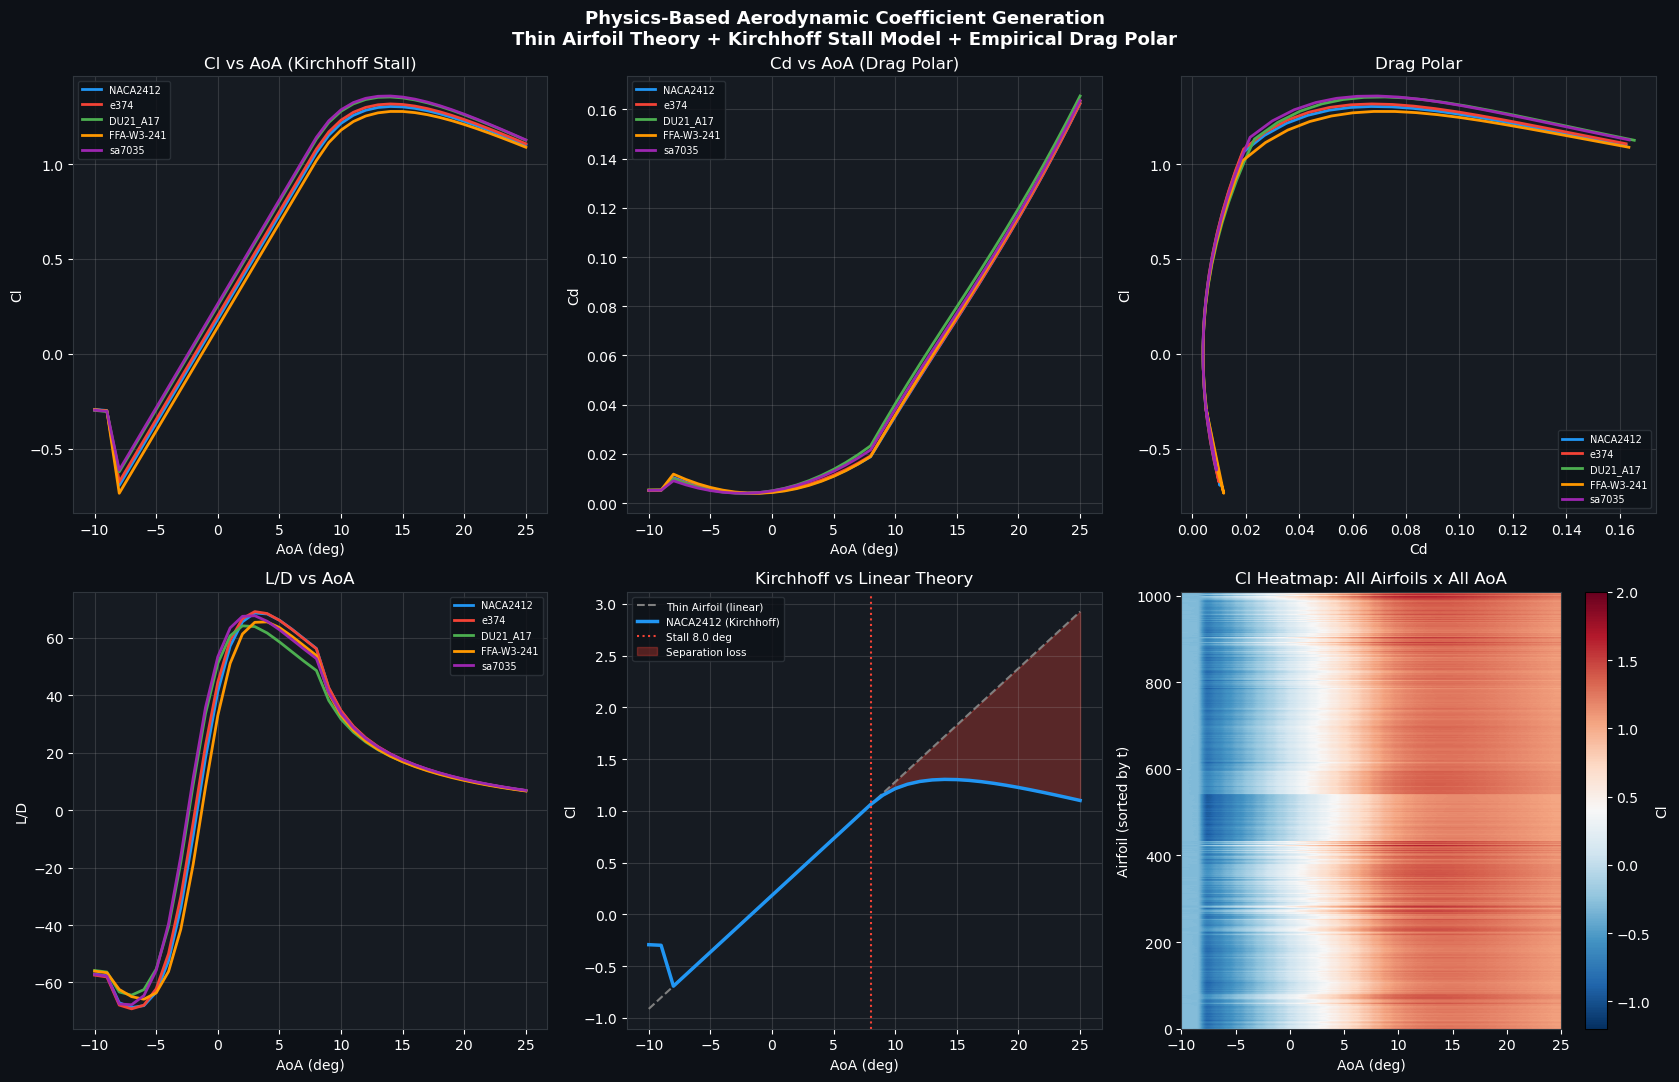

In [52]:
fig2, axes = dark_fig(2, 3, (17, 11),
    "Physics-Based Aerodynamic Coefficient Generation\n"
    "Thin Airfoil Theory + Kirchhoff Stall Model + Empirical Drag Polar")
 
rep_names  = ["NACA2412", "e374", "DU21_A17", "FFA-W3-241", "sa7035"]
rep_colors = [C1, C2, C3, C4, C5]
rep_idx    = [int(np.where(valid_cls == nm)[0][0])
              for nm in rep_names if np.any(valid_cls == nm)]
 
for ri, nm, col in zip(rep_idx, rep_names, rep_colors):
    axes[0, 0].plot(alpha_deg, Cl_all[ri], color=col, lw=2, label=nm)
    axes[0, 1].plot(alpha_deg, Cd_all[ri], color=col, lw=2, label=nm)
    axes[0, 2].plot(Cd_all[ri], Cl_all[ri], color=col, lw=2, label=nm)
    LD_i = np.clip(Cl_all[ri] / np.clip(Cd_all[ri], 1e-4, None), -80, 80)
    axes[1, 0].plot(alpha_deg, LD_i, color=col, lw=2, label=nm)

for ax, xl, yl, tl in [
    (axes[0, 0], "AoA (deg)", "Cl",  "Cl vs AoA (Kirchhoff Stall)"),
    (axes[0, 1], "AoA (deg)", "Cd",  "Cd vs AoA (Drag Polar)"),
    (axes[0, 2], "Cd",        "Cl",  "Drag Polar"),
    (axes[1, 0], "AoA (deg)", "L/D", "L/D vs AoA"),
]:
    ax.set_xlabel(xl); ax.set_ylabel(yl); ax.set_title(tl)
    leg(ax, fontsize=7); ax.grid(alpha=0.2)

ri0 = rep_idx[0]
Cl_lin_demo = 2 * np.pi * (np.deg2rad(alpha_deg) - alpha_L0[ri0])
axes[1, 1].plot(alpha_deg, Cl_lin_demo, color="gray", lw=1.5, ls="--",
                label="Thin Airfoil (linear)")
axes[1, 1].plot(alpha_deg, Cl_all[ri0], color=C1, lw=2.5,
                label=f"{rep_names[0]} (Kirchhoff)")
axes[1, 1].axvline(alpha_stall[ri0], color=C2, lw=1.5, ls=":",
                    label=f"Stall {alpha_stall[ri0]:.1f} deg")
axes[1, 1].fill_between(alpha_deg, Cl_lin_demo, Cl_all[ri0],
                         where=(alpha_deg > alpha_stall[ri0]),
                         alpha=0.3, color=C2, label="Separation loss")
axes[1, 1].set_xlabel("AoA (deg)"); axes[1, 1].set_ylabel("Cl")
axes[1, 1].set_title("Kirchhoff vs Linear Theory")
leg(axes[1, 1], fontsize=7.5); axes[1, 1].grid(alpha=0.2)
 
sort_ord = np.argsort(max_t)
Cl_hm    = Cl_all[sort_ord[::19], :]
im = axes[1, 2].imshow(Cl_hm, aspect="auto", cmap="RdBu_r",
                        extent=[alpha_deg[0], alpha_deg[-1], 0, Cl_hm.shape[0]],
                        vmin=-1.2, vmax=2.0, origin="lower")
cb_style(plt.colorbar(im, ax=axes[1, 2], label="Cl"))
axes[1, 2].set_xlabel("AoA (deg)"); axes[1, 2].set_ylabel("Airfoil (sorted by t)")
axes[1, 2].set_title("Cl Heatmap: All Airfoils x All AoA")
 
plt.tight_layout()
plt.show()

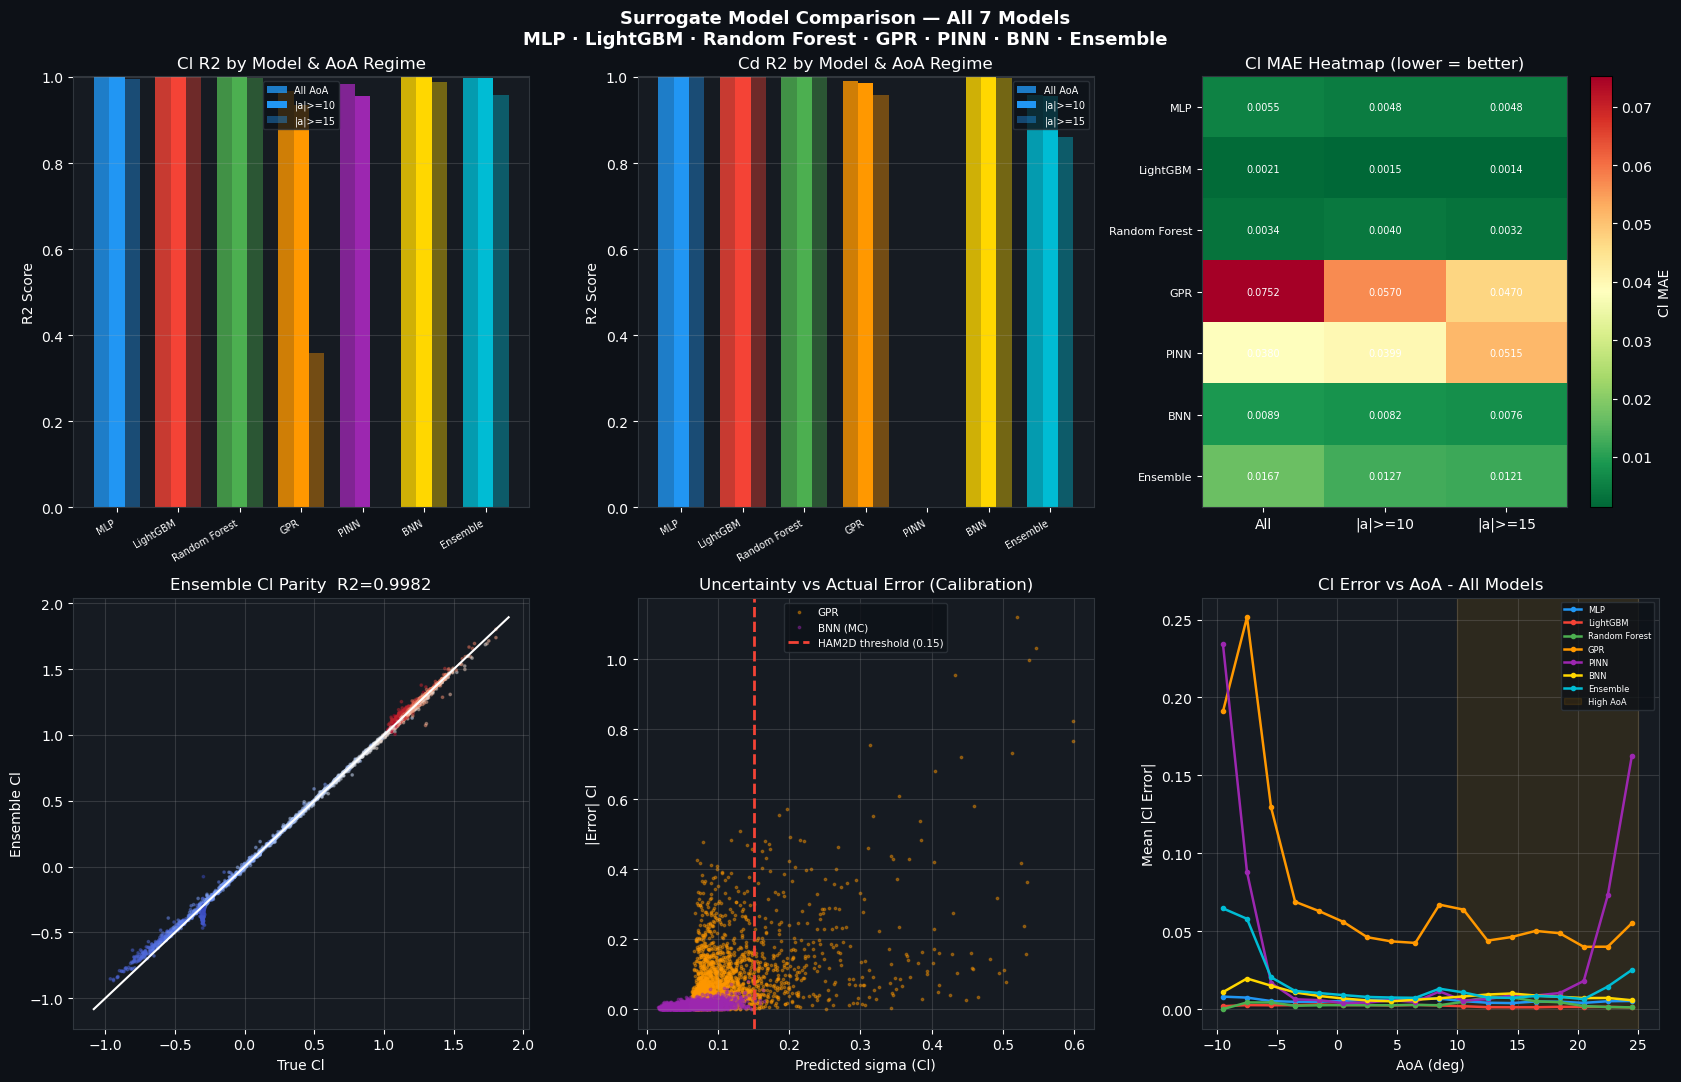

In [53]:
fig3, axes = dark_fig(2, 3, (17, 11),
    "Surrogate Model Comparison — All 7 Models\n"
    "MLP · LightGBM · Random Forest · GPR · PINN · BNN · Ensemble")
 
r2_Cl_all   = [r2_score(yCl_test, all_preds[m][0]) for m in model_order]
r2_Cl_high  = [r2_score(yCl_test[high],  all_preds[m][0][high])  for m in model_order]
r2_Cl_stall = [r2_score(yCl_test[stall], all_preds[m][0][stall]) for m in model_order]
 
x_pos = np.arange(len(model_order)); w = 0.25
axes[0, 0].bar(x_pos - w, r2_Cl_all,   w, color=[c+"CC" for c in model_colors], label="All AoA")
axes[0, 0].bar(x_pos,     r2_Cl_high,  w, color=model_colors,                   label="|a|>=10")
axes[0, 0].bar(x_pos + w, r2_Cl_stall, w, color=[c+"66" for c in model_colors], label="|a|>=15")
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(model_order, rotation=30, ha="right", fontsize=7)
axes[0, 0].set_ylabel("R2 Score"); axes[0, 0].set_title("Cl R2 by Model & AoA Regime")
axes[0, 0].set_ylim(max(0, min(r2_Cl_stall) - 0.02), 1.002)
leg(axes[0, 0], fontsize=7); axes[0, 0].grid(alpha=0.2, axis="y")
 
r2_Cd_all   = [r2_score(yCd_test, all_preds[m][1]) for m in model_order]
r2_Cd_high  = [r2_score(yCd_test[high],  all_preds[m][1][high])  for m in model_order]
r2_Cd_stall = [r2_score(yCd_test[stall], all_preds[m][1][stall]) for m in model_order]
 
axes[0, 1].bar(x_pos - w, r2_Cd_all,   w, color=[c+"CC" for c in model_colors], label="All AoA")
axes[0, 1].bar(x_pos,     r2_Cd_high,  w, color=model_colors,                   label="|a|>=10")
axes[0, 1].bar(x_pos + w, r2_Cd_stall, w, color=[c+"66" for c in model_colors], label="|a|>=15")
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(model_order, rotation=30, ha="right", fontsize=7)
axes[0, 1].set_ylabel("R2 Score"); axes[0, 1].set_title("Cd R2 by Model & AoA Regime")
axes[0, 1].set_ylim(max(0, min(r2_Cd_stall) - 0.02), 1.002)
leg(axes[0, 1], fontsize=7); axes[0, 1].grid(alpha=0.2, axis="y")
 
# Cl MAE heatmap across models and regimes
mae_matrix = np.array([[mean_absolute_error(yCl_test, all_preds[m][0]),
                         mean_absolute_error(yCl_test[high],  all_preds[m][0][high]),
                         mean_absolute_error(yCl_test[stall], all_preds[m][0][stall])]
                        for m in model_order])
im = axes[0, 2].imshow(mae_matrix, cmap="RdYlGn_r", aspect="auto")
axes[0, 2].set_xticks([0, 1, 2])
axes[0, 2].set_xticklabels(["All", "|a|>=10", "|a|>=15"])
axes[0, 2].set_yticks(range(len(model_order)))
axes[0, 2].set_yticklabels(model_order, fontsize=8)
axes[0, 2].set_title("Cl MAE Heatmap (lower = better)")
for i in range(len(model_order)):
    for j in range(3):
        axes[0, 2].text(j, i, f"{mae_matrix[i,j]:.4f}", ha="center", va="center",
                         fontsize=7, color="white")
cb_style(plt.colorbar(im, ax=axes[0, 2], label="Cl MAE"))
 
# Ensemble parity plot
n_show   = min(3000, len(yCl_test))
idx_show = rng.choice(len(yCl_test), n_show, replace=False)
axes[1, 0].scatter(yCl_test[idx_show], Cl_pred_ens[idx_show],
                    c=alpha_test[idx_show], cmap="coolwarm", alpha=0.4, s=3)
lim = [min(yCl_test.min(), Cl_pred_ens.min()), max(yCl_test.max(), Cl_pred_ens.max())]
axes[1, 0].plot(lim, lim, "w-", lw=1.5)
axes[1, 0].set_xlabel("True Cl"); axes[1, 0].set_ylabel("Ensemble Cl")
axes[1, 0].set_title(f"Ensemble Cl Parity  R2={r2_score(yCl_test, Cl_pred_ens):.4f}")
axes[1, 0].grid(alpha=0.2)
 
# Uncertainty vs actual error (calibration check)
axes[1, 1].scatter(Cl_gpr_std[idx_show],
                    np.abs(yCl_test[idx_show] - Cl_pred_gpr[idx_show]),
                    color=C4, alpha=0.4, s=3, label="GPR")
axes[1, 1].scatter(Cl_bnn_std[idx_show],
                    np.abs(yCl_test[idx_show] - Cl_pred_bnn[idx_show]),
                    color=C5, alpha=0.4, s=3, label="BNN (MC)")
axes[1, 1].axvline(UQ_THRESHOLD_CL, color=C2, lw=2, ls="--",
                    label=f"HAM2D threshold ({UQ_THRESHOLD_CL})")
axes[1, 1].set_xlabel("Predicted sigma (Cl)"); axes[1, 1].set_ylabel("|Error| Cl")
axes[1, 1].set_title("Uncertainty vs Actual Error (Calibration)")
leg(axes[1, 1], fontsize=7.5); axes[1, 1].grid(alpha=0.2)
 
# Cl error vs AoA for all models
bins     = np.arange(-10.5, 26, 2)
centers  = (bins[:-1] + bins[1:]) / 2
for m_name, col in zip(model_order, model_colors):
    Cl_p = all_preds[m_name][0]
    errs = []
    for i in range(len(bins) - 1):
        mask = (alpha_test >= bins[i]) & (alpha_test < bins[i + 1])
        errs.append(np.abs(Cl_p[mask] - yCl_test[mask]).mean() if mask.sum() > 5 else np.nan)
    axes[1, 2].plot(centers, errs, color=col, lw=1.8, marker="o", ms=3, label=m_name)
axes[1, 2].axvspan(10, 25, alpha=0.1, color="orange", label="High AoA")
axes[1, 2].set_xlabel("AoA (deg)"); axes[1, 2].set_ylabel("Mean |Cl Error|")
axes[1, 2].set_title("Cl Error vs AoA - All Models")
leg(axes[1, 2], fontsize=6); axes[1, 2].grid(alpha=0.2)
 
plt.tight_layout()
plt.show()

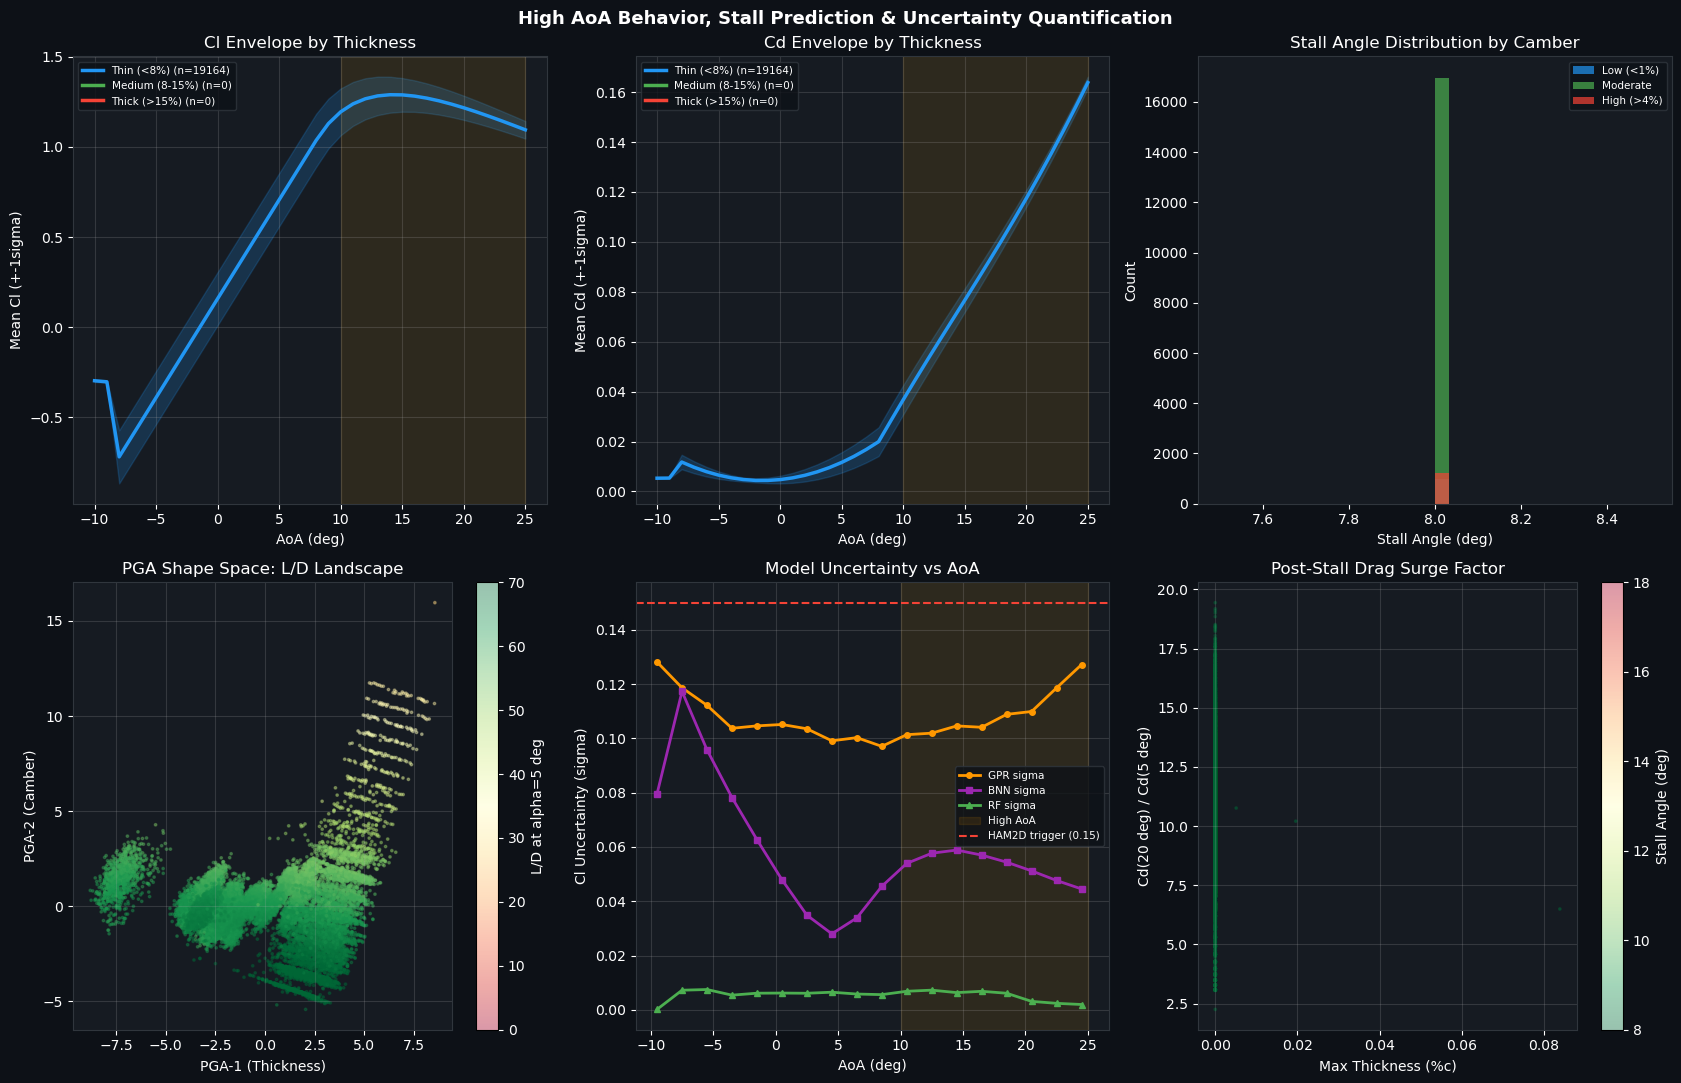

In [54]:
fig4, axes = dark_fig(2, 3, (17, 11),
    "High AoA Behavior, Stall Prediction & Uncertainty Quantification")
 
thick_bins = [(0, 0.08, "Thin (<8%)", C1),
              (0.08, 0.15, "Medium (8-15%)", C3),
              (0.15, 0.45, "Thick (>15%)", C2)]
 
for t_lo, t_hi, lbl, col in thick_bins:
    m = (max_t >= t_lo) & (max_t < t_hi)
    for ax, arr in [(axes[0, 0], Cl_all), (axes[0, 1], Cd_all)]:
        mn, sd = arr[m].mean(0), arr[m].std(0)
        ax.plot(alpha_deg, mn, color=col, lw=2.5, label=f"{lbl} (n={m.sum()})")
        ax.fill_between(alpha_deg, mn - sd, mn + sd, alpha=0.2, color=col)
 
for ax, yl, tl in [(axes[0, 0], "Mean Cl (+-1sigma)", "Cl Envelope by Thickness"),
                    (axes[0, 1], "Mean Cd (+-1sigma)", "Cd Envelope by Thickness")]:
    ax.axvspan(10, 25, alpha=0.1, color="orange")
    ax.set_xlabel("AoA (deg)"); ax.set_ylabel(yl); ax.set_title(tl)
    leg(ax, fontsize=7.5); ax.grid(alpha=0.2)
 
camber_bins = [(0, 0.01, "Low (<1%)", C1),
               (0.01, 0.04, "Moderate", C3),
               (0.04, 0.15, "High (>4%)", C2)]
for c_lo, c_hi, lbl, col in camber_bins:
    m = (max_c >= c_lo) & (max_c < c_hi)
    axes[0, 2].hist(alpha_stall[m], bins=30, alpha=0.7, color=col, label=lbl)
axes[0, 2].set_xlabel("Stall Angle (deg)"); axes[0, 2].set_ylabel("Count")
axes[0, 2].set_title("Stall Angle Distribution by Camber")
leg(axes[0, 2], fontsize=7.5)
 
# PGA landscape with L/D
sc = axes[1, 0].scatter(pga_coords[:, 0], pga_coords[:, 1],
                         c=np.clip(LD_5, 0, 80), cmap="RdYlGn",
                         alpha=0.4, s=3, vmin=0, vmax=70)
cb_style(plt.colorbar(sc, ax=axes[1, 0], label="L/D at alpha=5 deg"))
axes[1, 0].set_xlabel("PGA-1 (Thickness)"); axes[1, 0].set_ylabel("PGA-2 (Camber)")
axes[1, 0].set_title("PGA Shape Space: L/D Landscape"); axes[1, 0].grid(alpha=0.2)
 
# Uncertainty vs AoA for GPR, BNN, RF
bins2    = np.arange(-10.5, 26, 2)
centers2 = (bins2[:-1] + bins2[1:]) / 2
gpr_unc, bnn_unc, rf_unc = [], [], []
for i in range(len(bins2) - 1):
    m = (alpha_test >= bins2[i]) & (alpha_test < bins2[i + 1])
    gpr_unc.append(Cl_gpr_std[m].mean() if m.sum() > 5 else np.nan)
    bnn_unc.append(Cl_bnn_std[m].mean() if m.sum() > 5 else np.nan)
    rf_unc.append(Cl_rf_std[m].mean()   if m.sum() > 5 else np.nan)

axes[1, 1].plot(centers2, gpr_unc, color=C4, lw=2, marker="o", ms=4, label="GPR sigma")
axes[1, 1].plot(centers2, bnn_unc, color=C5, lw=2, marker="s", ms=4, label="BNN sigma")
axes[1, 1].plot(centers2, rf_unc,  color=C3, lw=2, marker="^", ms=4, label="RF sigma")
axes[1, 1].axvspan(10, 25, alpha=0.1, color="orange", label="High AoA")
axes[1, 1].axhline(UQ_THRESHOLD_CL, color=C2, lw=1.5, ls="--",
                    label=f"HAM2D trigger ({UQ_THRESHOLD_CL})")
axes[1, 1].set_xlabel("AoA (deg)"); axes[1, 1].set_ylabel("Cl Uncertainty (sigma)")
axes[1, 1].set_title("Model Uncertainty vs AoA")
leg(axes[1, 1], fontsize=7.5); axes[1, 1].grid(alpha=0.2)
 
# Post-stall drag surge
idx_20   = int(np.argmin(np.abs(alpha_deg - 20)))
Cd_ratio = Cd_all[:, idx_20] / np.clip(Cd_all[:, idx_5], 1e-4, None)
sc = axes[1, 2].scatter(max_t * 100, Cd_ratio, c=alpha_stall,
                         cmap="RdYlGn_r", alpha=0.4, s=3, vmin=8, vmax=18)
cb_style(plt.colorbar(sc, ax=axes[1, 2], label="Stall Angle (deg)"))
axes[1, 2].set_xlabel("Max Thickness (%c)"); axes[1, 2].set_ylabel("Cd(20 deg) / Cd(5 deg)")
axes[1, 2].set_title("Post-Stall Drag Surge Factor"); axes[1, 2].grid(alpha=0.2)
 
plt.tight_layout()
plt.show()

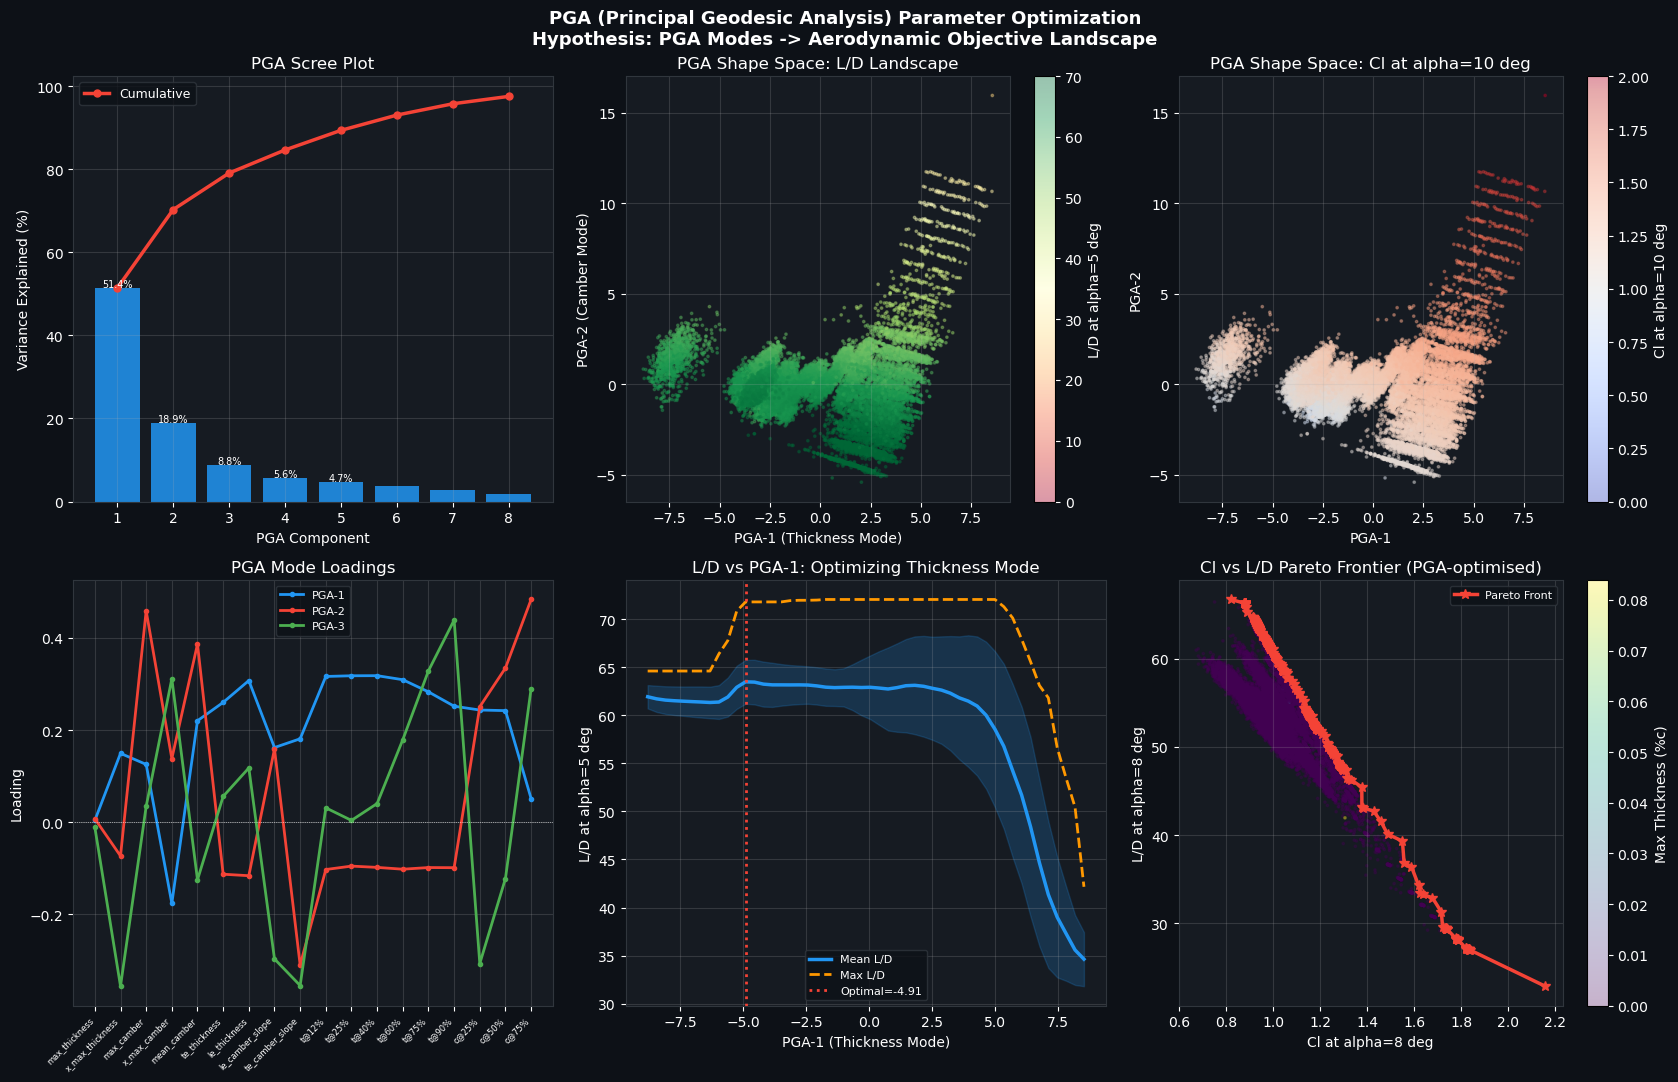

In [55]:
fig5, axes = dark_fig(2, 3, (17, 11),
    "PGA (Principal Geodesic Analysis) Parameter Optimization\n"
    "Hypothesis: PGA Modes -> Aerodynamic Objective Landscape")
 
axes[0, 0].bar(range(1, 9), expl_var * 100, color=C1, alpha=0.85)
axes[0, 0].plot(range(1, 9), np.cumsum(expl_var) * 100,
                color=C2, lw=2.5, marker="o", ms=5, label="Cumulative")
for i, v in enumerate(expl_var[:5]):
    axes[0, 0].text(i + 1, v * 100 + 0.3, f"{v*100:.1f}%",
                     ha="center", fontsize=7, color="white")
axes[0, 0].set_xlabel("PGA Component"); axes[0, 0].set_ylabel("Variance Explained (%)")
axes[0, 0].set_title("PGA Scree Plot")
leg(axes[0, 0], fontsize=9); axes[0, 0].grid(alpha=0.2)
 
sc = axes[0, 1].scatter(pga_coords[:, 0], pga_coords[:, 1], c=LD_5,
                         cmap="RdYlGn", alpha=0.4, s=3, vmin=0, vmax=70)
cb_style(plt.colorbar(sc, ax=axes[0, 1], label="L/D at alpha=5 deg"))
axes[0, 1].set_xlabel("PGA-1 (Thickness Mode)"); axes[0, 1].set_ylabel("PGA-2 (Camber Mode)")
axes[0, 1].set_title("PGA Shape Space: L/D Landscape"); axes[0, 1].grid(alpha=0.2)
 
sc = axes[0, 2].scatter(pga_coords[:, 0], pga_coords[:, 1],
                         c=Cl_all[:, int(np.argmin(np.abs(alpha_deg - 10)))],
                         cmap="coolwarm", alpha=0.4, s=3, vmin=0, vmax=2.0)
cb_style(plt.colorbar(sc, ax=axes[0, 2], label="Cl at alpha=10 deg"))
axes[0, 2].set_xlabel("PGA-1"); axes[0, 2].set_ylabel("PGA-2")
axes[0, 2].set_title("PGA Shape Space: Cl at alpha=10 deg"); axes[0, 2].grid(alpha=0.2)
 
for i, (col, lbl) in enumerate(zip([C1, C2, C3], ["PGA-1", "PGA-2", "PGA-3"])):
    axes[1, 0].plot(range(len(FEATURE_NAMES)), pca.components_[i],
                     color=col, lw=2, marker="o", ms=3, label=lbl)
axes[1, 0].axhline(0, color="white", lw=0.5, ls=":")
axes[1, 0].set_xticks(range(len(FEATURE_NAMES)))
axes[1, 0].set_xticklabels(FEATURE_NAMES, rotation=45, ha="right", fontsize=6)
axes[1, 0].set_ylabel("Loading"); axes[1, 0].set_title("PGA Mode Loadings")
leg(axes[1, 0], fontsize=8); axes[1, 0].grid(alpha=0.2)
 
std_LD2    = []
max_LD_arr = []
for p1 in pga1_range:
    mask = np.abs(pga_coords[:, 0] - p1) < window
    ld   = np.clip(LD_5[mask], 0, 80) if mask.sum() > 5 else np.array([np.nan])
    std_LD2.append(ld.std())
    max_LD_arr.append(ld.max())
std_LD2 = np.array(std_LD2); max_LD_arr = np.array(max_LD_arr)
 
axes[1, 1].plot(pga1_range, mean_LD, color=C1, lw=2.5, label="Mean L/D")
axes[1, 1].fill_between(pga1_range, mean_LD - std_LD2, mean_LD + std_LD2,
                          alpha=0.2, color=C1)
axes[1, 1].plot(pga1_range, max_LD_arr, color=C4, lw=2, ls="--", label="Max L/D")
axes[1, 1].axvline(opt_pga1, color=C2, lw=2, ls=":", label=f"Optimal={opt_pga1:.2f}")
axes[1, 1].set_xlabel("PGA-1 (Thickness Mode)"); axes[1, 1].set_ylabel("L/D at alpha=5 deg")
axes[1, 1].set_title("L/D vs PGA-1: Optimizing Thickness Mode")
leg(axes[1, 1], fontsize=8); axes[1, 1].grid(alpha=0.2)
 
Cl_8 = Cl_all[:, idx_8]; LD_8 = np.clip(LD_all[:, idx_8], 0, 80)
sc = axes[1, 2].scatter(Cl_8, LD_8, c=max_t * 100, cmap="viridis", alpha=0.3, s=3)
cb_style(plt.colorbar(sc, ax=axes[1, 2], label="Max Thickness (%c)"))
so = np.argsort(Cl_8); Cl_s = Cl_8[so]; LD_s = LD_8[so]
pf = np.zeros(len(Cl_s), bool); best_ld = -np.inf
for i in range(len(Cl_s) - 1, -1, -1):
    if LD_s[i] > best_ld:
        pf[i] = True; best_ld = LD_s[i]
axes[1, 2].plot(Cl_s[pf], LD_s[pf], color=C2, lw=2.5, marker="*",
                ms=7, zorder=5, label="Pareto Front")
axes[1, 2].set_xlabel("Cl at alpha=8 deg"); axes[1, 2].set_ylabel("L/D at alpha=8 deg")
axes[1, 2].set_title("Cl vs L/D Pareto Frontier (PGA-optimised)")
leg(axes[1, 2], fontsize=8); axes[1, 2].grid(alpha=0.2)
 
plt.tight_layout()
plt.show()